In [1]:
!pip install SimpleITK monai tqdm matplotlib torchsummary -q


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 MB 20.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 60.6 MB/s eta 0:00:00


In [2]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [3]:
import os, warnings
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from monai.networks.nets import DenseNet121

warnings.filterwarnings('ignore')

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
BASE_DIR       = '/content/drive/MyDrive/LUNA16_Project'
STAGE1_PATH    = os.path.join(BASE_DIR, 'best_stage1_detector.pth')
STAGE2_PATH    = os.path.join(BASE_DIR, 'best_stage2_fpr_model.pth')

print(f'Device          : {DEVICE}')
print(f'Stage 1 model   : {os.path.exists(STAGE1_PATH)}')
print(f'Stage 2 model   : {os.path.exists(STAGE2_PATH)}')


<frozen importlib._bootstrap_external>:1301: FutureWarning: The cuda.cudart module is deprecated and will be removed in a future release, please switch to use the cuda.bindings.runtime module instead.


Device          : cuda
Stage 1 model   : True
Stage 2 model   : True


In [4]:
# ── Instantiate the model (same config used in Stage 1 & Stage 2) ─────────────
model = DenseNet121(
    spatial_dims = 3,      # 3-D convolutions throughout
    in_channels  = 1,      # single-channel CT (greyscale HU)
    out_channels = 2,      # binary: negative (0) vs nodule (1)
).to(DEVICE)

print(model)


DenseNet121(
  (features): Sequential(
    (conv0): Conv3d(1, 64, kernel_size=(7, 7, 7), stride=(2, 2, 2), padding=(3, 3, 3), bias=False)
    (norm0): BatchNorm3d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu0): ReLU(inplace=True)
    (pool0): MaxPool3d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (denseblock1): _DenseBlock(
      (denselayer1): _DenseLayer(
        (layers): Sequential(
          (norm1): BatchNorm3d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (relu1): ReLU(inplace=True)
          (conv1): Conv3d(64, 128, kernel_size=(1, 1, 1), stride=(1, 1, 1), bias=False)
          (norm2): BatchNorm3d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (relu2): ReLU(inplace=True)
          (conv2): Conv3d(128, 32, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1), bias=False)
        )
      )
      (denselayer2): _DenseLayer(
        (layers): Sequential(
 

---
## Section 2 — Parameter Count & Memory Estimate

In [5]:
def count_parameters(m):
    total     = sum(p.numel() for p in m.parameters())
    trainable = sum(p.numel() for p in m.parameters() if p.requires_grad)
    return total, trainable

total, trainable = count_parameters(model)

print('=' * 50)
print('  DenseNet-121 (3-D) — Parameter Summary')
print('=' * 50)
print(f'  Total parameters      : {total:>12,}')
print(f'  Trainable parameters  : {trainable:>12,}')
print(f'  Non-trainable params  : {total - trainable:>12,}')
print()
# Memory estimate: each float32 param = 4 bytes
mem_mb = total * 4 / 1024**2
print(f'  Model weight memory   : {mem_mb:.1f} MB  (fp32)')
print(f'  Model weight memory   : {mem_mb/2:.1f} MB  (fp16 / AMP)')
print('=' * 50)


  DenseNet-121 (3-D) — Parameter Summary
  Total parameters      :   11,244,674
  Trainable parameters  :   11,244,674
  Non-trainable params  :            0

  Model weight memory   : 42.9 MB  (fp32)
  Model weight memory   : 21.4 MB  (fp16 / AMP)


In [6]:
# ── Layer-by-layer breakdown ──────────────────────────────────────────────────
print(f'{'Layer name':<50} {'Params':>12}')
print('-' * 65)
total_shown = 0
for name, module in model.named_modules():
    n = sum(p.numel() for p in module.parameters(recurse=False))
    if n > 0:
        print(f'{name:<50} {n:>12,}')
        total_shown += n
print('-' * 65)
print(f'{'TOTAL':<50} {total_shown:>12,}')


Layer name                                               Params
-----------------------------------------------------------------
features.conv0                                           21,952
features.norm0                                              128
features.denseblock1.denselayer1.layers.norm1               128
features.denseblock1.denselayer1.layers.conv1             8,192
features.denseblock1.denselayer1.layers.norm2               256
features.denseblock1.denselayer1.layers.conv2           110,592
features.denseblock1.denselayer2.layers.norm1               192
features.denseblock1.denselayer2.layers.conv1            12,288
features.denseblock1.denselayer2.layers.norm2               256
features.denseblock1.denselayer2.layers.conv2           110,592
features.denseblock1.denselayer3.layers.norm1               256
features.denseblock1.denselayer3.layers.conv1            16,384
features.denseblock1.denselayer3.layers.norm2               256
features.denseblock1.denselayer3.layer

---
## Section 3 — Forward-Pass Smoke Test


In [8]:
model.eval()

# Simulate a batch of 4 patches — same shape used during training
dummy_input = torch.zeros(4, 1, 64, 64, 64, device=DEVICE)

with torch.no_grad():
    logits = model(dummy_input)
    probs  = torch.softmax(logits, dim=1)

print('Input  shape :', dummy_input.shape)
print('Logits shape :', logits.shape)
print('Probs  shape :', probs.shape)
print()
print('Sample logits (first item):', logits[0].cpu().numpy().round(4))
print('Sample probs  (first item):', probs[0].cpu().numpy().round(4))
print()
assert logits.shape == (4, 2), 'Unexpected output shape!'
print(' Forward pass OK')


Input  shape : torch.Size([4, 1, 64, 64, 64])
Logits shape : torch.Size([4, 2])
Probs  shape : torch.Size([4, 2])

Sample logits (first item): [0. 0.]
Sample probs  (first item): [0.5 0.5]

 Forward pass OK


---
## Section 4 — Feature-Map Shape Trace

Registers forward hooks on every Conv3d layer to record the output spatial dimensions as data flows through the network.

In [9]:
shape_log = []

def _hook(module, inp, out):
    shape_log.append((module.__class__.__name__, tuple(out.shape)))

hooks = []
for name, module in model.named_modules():
    if isinstance(module, nn.Conv3d):
        hooks.append(module.register_forward_hook(_hook))

dummy = torch.zeros(1, 1, 64, 64, 64, device=DEVICE)
with torch.no_grad():
    _ = model(dummy)

for h in hooks:
    h.remove()

print(f'{'Layer':<20} {'Output shape':>30}')
print('-' * 55)
for i, (name, shape) in enumerate(shape_log):
    print(f'{i:>3}. {name:<18} {str(shape):>30}')


Layer                                  Output shape
-------------------------------------------------------
  0. Conv3d                        (1, 64, 32, 32, 32)
  1. Conv3d                       (1, 128, 16, 16, 16)
  2. Conv3d                        (1, 32, 16, 16, 16)
  3. Conv3d                       (1, 128, 16, 16, 16)
  4. Conv3d                        (1, 32, 16, 16, 16)
  5. Conv3d                       (1, 128, 16, 16, 16)
  6. Conv3d                        (1, 32, 16, 16, 16)
  7. Conv3d                       (1, 128, 16, 16, 16)
  8. Conv3d                        (1, 32, 16, 16, 16)
  9. Conv3d                       (1, 128, 16, 16, 16)
 10. Conv3d                        (1, 32, 16, 16, 16)
 11. Conv3d                       (1, 128, 16, 16, 16)
 12. Conv3d                        (1, 32, 16, 16, 16)
 13. Conv3d                       (1, 128, 16, 16, 16)
 14. Conv3d                          (1, 128, 8, 8, 8)
 15. Conv3d                           (1, 32, 8, 8, 8)
 16. Conv3d 

---
## Section 6 — Parameter Distribution Visualisation

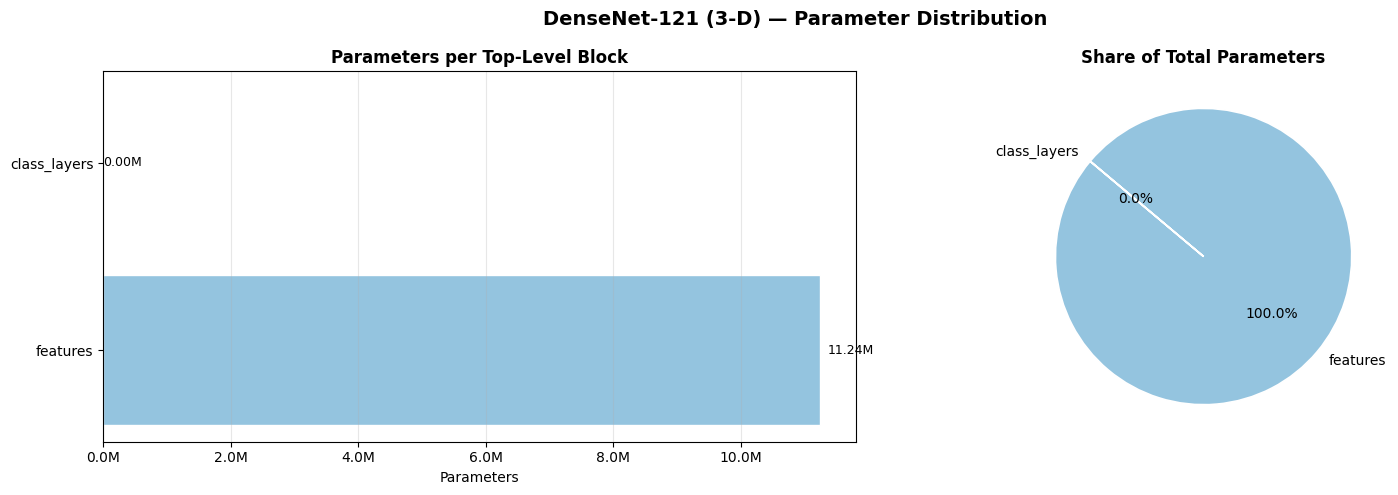

Saved → densenet121_param_distribution.png


In [10]:
# ── Collect per-block parameter counts ───────────────────────────────────────
block_names, block_params = [], []

for name, module in model.named_children():
    n = sum(p.numel() for p in module.parameters())
    block_names.append(name)
    block_params.append(n)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('DenseNet-121 (3-D) — Parameter Distribution', fontsize=14, fontweight='bold')

# Bar chart
colors = plt.cm.Blues(np.linspace(0.4, 0.9, len(block_names)))
bars = axes[0].barh(block_names, block_params, color=colors, edgecolor='white')
for bar, val in zip(bars, block_params):
    axes[0].text(bar.get_width() * 1.01, bar.get_y() + bar.get_height()/2,
                 f'{val/1e6:.2f}M', va='center', fontsize=9)
axes[0].set_xlabel('Parameters')
axes[0].set_title('Parameters per Top-Level Block', fontweight='bold')
axes[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f'{x/1e6:.1f}M'))
axes[0].grid(axis='x', alpha=0.3)

# Pie chart
axes[1].pie(block_params, labels=block_names, autopct='%1.1f%%',
            colors=colors, startangle=140,
            wedgeprops={'edgecolor': 'white', 'linewidth': 1.2})
axes[1].set_title('Share of Total Parameters', fontweight='bold')

plt.tight_layout()
plt.savefig('densenet121_param_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → densenet121_param_distribution.png')


---
## Section 8 — Stage 1 vs Stage 2 Head Comparison


In [15]:
def load_model(path, label):
    m = DenseNet121(spatial_dims=3, in_channels=1, out_channels=2)
    if os.path.exists(path):
        state = torch.load(path, map_location='cpu')
        m.load_state_dict(state)
        print(f'  {label} loaded from {path}')
    else:
        print(f'   {label} not found at {path} — using random weights for demo')
    m.eval()
    return m

model_s1 = load_model(STAGE1_PATH, 'Stage 1 Detector')
model_s2 = load_model(STAGE2_PATH, 'Stage 2 FPR')


  Stage 1 Detector loaded from /content/drive/MyDrive/LUNA16_Project/best_stage1_detector.pth
  Stage 2 FPR loaded from /content/drive/MyDrive/LUNA16_Project/best_stage2_fpr_model.pth


Classifier head weight shape: torch.Size([2, 1024])

Stage 1 — mean: 0.00079  std: 0.01808
Stage 2 — mean: 0.00035  std: 0.01763
Cosine similarity (S1 vs S2 head): 0.0120
(A value close to 0 confirms the two heads have diverged via independent training.)


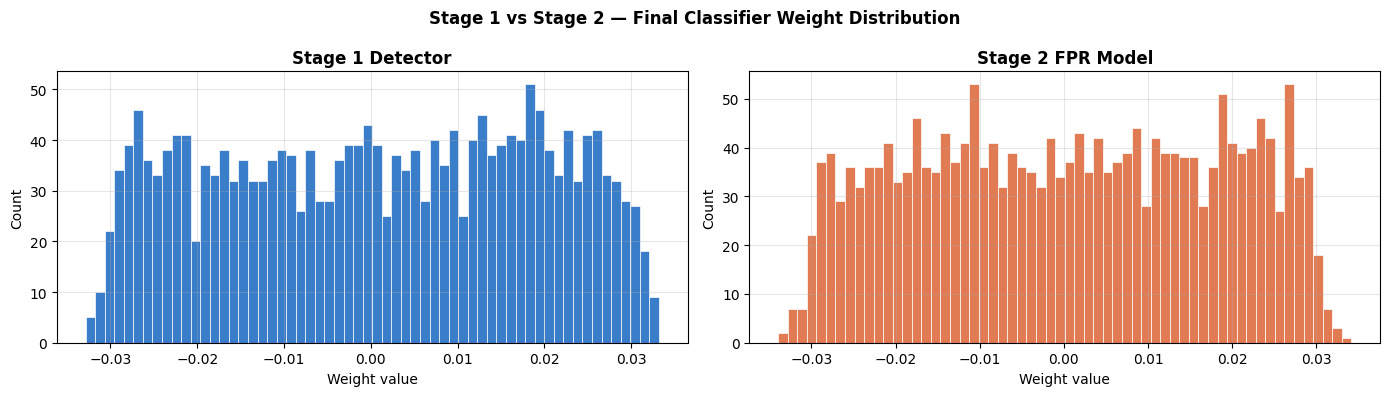

Saved → densenet121_head_comparison.png


In [13]:
# Compare the final classifier (out.weight)
w1 = None
w2 = None
for name, p in model_s1.named_parameters():
    if 'out' in name and 'weight' in name:
        w1 = p.data.cpu()
for name, p in model_s2.named_parameters():
    if 'out' in name and 'weight' in name:
        w2 = p.data.cpu()

if w1 is not None and w2 is not None:
    print('Classifier head weight shape:', w1.shape)
    print()
    print(f'Stage 1 — mean: {w1.mean():.5f}  std: {w1.std():.5f}')
    print(f'Stage 2 — mean: {w2.mean():.5f}  std: {w2.std():.5f}')
    cosine_sim = torch.nn.functional.cosine_similarity(
        w1.view(1,-1), w2.view(1,-1)).item()
    print(f'Cosine similarity (S1 vs S2 head): {cosine_sim:.4f}')
    print('(A value close to 0 confirms the two heads have diverged via independent training.)')

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle('Stage 1 vs Stage 2 — Final Classifier Weight Distribution', fontweight='bold')

for ax, w, label, color in zip(
        axes,
        [w1, w2],
        ['Stage 1 Detector', 'Stage 2 FPR Model'],
        ['#3A7DC9', '#E07B54']):
    ax.hist(w.numpy().flatten(), bins=60, color=color, edgecolor='white', linewidth=0.5)
    ax.set_title(label, fontweight='bold')
    ax.set_xlabel('Weight value')
    ax.set_ylabel('Count')
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('densenet121_head_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → densenet121_head_comparison.png')


In [14]:
print('=' * 58)
print('  DenseNet-121 Architecture Notebook — Complete')
print('=' * 58)
print(f'  Architecture   : 3-D DenseNet-121 (MONAI)')
print(f'  Input patch    : 1 × 64 × 64 × 64')
print(f'  Output         : 2-class logits (neg / nodule)')
total, _ = count_parameters(model)
print(f'  Parameters     : {total:,}  (~{total*4/1024**2:.1f} MB fp32)')
print(f'  Stage 1 model  : best_stage1_detector.pth')
print(f'  Stage 2 model  : best_stage2_fpr_model.pth')
print('=' * 58)


  DenseNet-121 Architecture Notebook — Complete
  Architecture   : 3-D DenseNet-121 (MONAI)
  Input patch    : 1 × 64 × 64 × 64
  Output         : 2-class logits (neg / nodule)
  Parameters     : 11,244,674  (~42.9 MB fp32)
  Stage 1 model  : best_stage1_detector.pth
  Stage 2 model  : best_stage2_fpr_model.pth
